##### Case - Study = Spam Detection

the main aim of this project - to demonstarte the basics of NLP (Natural Language Processing)

###### Major steos invovled :
* 1.) Text data visualization
* 2.) Text Data Prepprocessing
* 3.) Text Data to Numerical Vector Conversion using BOW ( Bag Of Words)

Steps :
* 1) Data Loading
  2) EDA
  3) Data Preparation
     - Train Test SPlit
     - Data Preprocessing(Special Char, Stop Words, Lower case,Stemming, etc)
     - Converting text to numerical vector using Bag Of Words.
  4) Training on train data
  5) Prediction on test data 
  6) Model Evaluation

#### 1.) Importing Prerequisite Libraries 

In [2]:
# absic data handling
import pandas as pd  # for handling Datasets(like CSVs, Excel, Json etc)
import numpy as np   # for numerical operations and arrays

# Text Preprocessing 
import re            # for regex operation (cleaning text)
import string        # for Punctuation handling 
import nltk          # Natural Lnaguage ToolKit (for Stopwords, stemming etc)
from nltk.corpus import stopwords   # To remove common, meaningless words like 'the','is','it'....
from nltk.stem import PorterStemmer # for Stemming
from nltk.stem import WordNetLemmatizer # for lemmatiztion

# Sklearn feature extraction (Data Transformation Model)
from sklearn.feature_extraction.text import CountVectorizer  # Bag of Words model
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF model]

# Data Preprocessing and Model Building 
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB   #classifier for text data
from sklearn.linear_model import LogisticRegression #another good text classifier
from sklearn.svm import SVC   #Support Vector Classifier 

# model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# visualization
import matplotlib.pyplot as plt 
import seaborn as sns

# progress bar  for loops and apply
from tqdm import tqdm  # to visually track long operations
tqdm.pandas()        #enable progress_apply() in pandas 

# download ntlk resources  ( only need to do once )
#nltk.download('stopwords')
#nltk.download('wordnet')    #for lemmatizer



Read the data 

In [3]:
df = pd.read_csv('email_data.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0


In [4]:
df.shape

(5171, 4)

EDA

In [5]:
df['label'].value_counts()

label
ham     3672
spam    1499
Name: count, dtype: int64

In [6]:
df['label'].value_counts(normalize = True)

label
ham     0.710114
spam    0.289886
Name: proportion, dtype: float64

<Axes: xlabel='label', ylabel='count'>

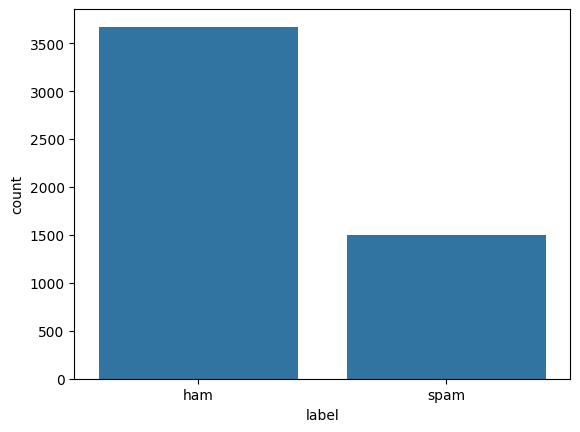

In [7]:
sns.countplot(x = 'label',data = df)

data preparation - split the data into train and test set

In [8]:
df.columns

Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')

In [9]:
df = df.drop('Unnamed: 0', axis = 1)

In [10]:
df.head()

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\nthis deal is to ...,0


In [16]:
#segregate the data into x and y 
y = df['label']
x = df[['text']]

In [17]:
x

,text
0,Subject: enron methanol ; meter # : 988291\nth...
1,"Subject: hpl nom for january 9 , 2001\n( see a..."
2,"Subject: neon retreat\nho ho ho , we ' re arou..."
3,"Subject: photoshop , windows , office . cheap ..."
4,Subject: re : indian springs\nthis deal is to ...
...,...
5166,Subject: put the 10 on the ft\nthe transport v...
5167,Subject: 3 / 4 / 2000 and following noms\nhpl ...
5168,Subject: calpine daily gas nomination\n>\n>\nj...
5169,Subject: industrial worksheets for august 2000...


In [20]:
#splitting into train and test 
X_train, X_test, Y_train, Y_test = train_test_split(x,y,test_size= 0.2, random_state=42)

In [21]:
X_train.head()

,text
5132,Subject: april activity surveys\nwe are starti...
2067,Subject: message subject\nhey i ' am julie ^ _...
4716,Subject: txu fuels / sds nomination for may 20...
4710,Subject: re : richardson volumes nov 99 and de...
2268,Subject: a new era of online medical care .\na...


In [22]:
X_train.shape

(4136, 1)

Data preparatiom - Text Preprocessing 

In [23]:
# initialising th inbuilt stemmer
stemmer = PorterStemmer()
#we can also use Lemmatizer instead of stemmer 
lemmatizer = WordNetLemmatizer()

In [24]:
def preprocess(raw_text,flag):
    #removing special character and digits 
    sentence = re.sub("[^a-zA-Z]"," ",raw_text)

    #change sentence to lower case
    sentence = sentence.lower()

    # tokenize into words
    tokens = sentence.split()

    # removing stop words 
    clean_tokens = [t for t in tokens if not t in stopwords.words("english")]

    #Stemming /lemmatization
    if(flag == 'stem'):
        clean_tokens = [stemmer.stem(word) for word in clean_tokens]
    else:
        clean_tokens = [lemmatizer.lemmatize(word) for word in clean_tokens]
    return pd.Series([" ".join(clean_tokens), len(clean_tokens)])

In [25]:
# now you can use progress_apply instead of 'apply'
temp_df = X_train['text'].progress_apply(lambda x: preprocess(x,'stem'))
temp_df.head()

100%|██████████████████████████████████████████████████████████████████████████████| 4136/4136 [03:49<00:00, 18.05it/s]


,0,1
5132,subject april activ survey start collect data ...,88
2067,subject messag subject hey juli turn high scho...,44
4716,subject txu fuel sd nomin may attach may nomin...,34
4710,subject richardson volum nov dec meter nick su...,105
2268,subject new era onlin medic care new era onlin...,36


In [26]:
temp_df.columns = ['clean_text_stem','text_length_stem']
temp_df.head()

,clean_text_stem,text_length_stem
5132,subject april activ survey start collect data ...,88
2067,subject messag subject hey juli turn high scho...,44
4716,subject txu fuel sd nomin may attach may nomin...,34
4710,subject richardson volum nov dec meter nick su...,105
2268,subject new era onlin medic care new era onlin...,36


In [27]:
X_train = pd.concat([X_train,temp_df],axis=1)
X_train.head()

,text,clean_text_stem,text_length_stem
5132,Subject: april activity surveys\nwe are starti...,subject april activ survey start collect data ...,88
2067,Subject: message subject\nhey i ' am julie ^ _...,subject messag subject hey juli turn high scho...,44
4716,Subject: txu fuels / sds nomination for may 20...,subject txu fuel sd nomin may attach may nomin...,34
4710,Subject: re : richardson volumes nov 99 and de...,subject richardson volum nov dec meter nick su...,105
2268,Subject: a new era of online medical care .\na...,subject new era onlin medic care new era onlin...,36


In [28]:
temp_df = X_train['text'].progress_apply(lambda x: preprocess(x,'lemma'))
temp_df.head()

100%|██████████████████████████████████████████████████████████████████████████████| 4136/4136 [03:28<00:00, 19.86it/s]


,0,1
5132,subject april activity survey starting collect...,88
2067,subject message subject hey julie turned high ...,44
4716,subject txu fuel sd nomination may attached ma...,34
4710,subject richardson volume nov dec meter nick s...,105
2268,subject new era online medical care new era on...,36


In [29]:
temp_df.head()

,0,1
5132,subject april activity survey starting collect...,88
2067,subject message subject hey julie turned high ...,44
4716,subject txu fuel sd nomination may attached ma...,34
4710,subject richardson volume nov dec meter nick s...,105
2268,subject new era online medical care new era on...,36


In [30]:
temp_df.columns = ['clean_text_lemma','text_length_lemma']
temp_df.head()

,clean_text_lemma,text_length_lemma
5132,subject april activity survey starting collect...,88
2067,subject message subject hey julie turned high ...,44
4716,subject txu fuel sd nomination may attached ma...,34
4710,subject richardson volume nov dec meter nick s...,105
2268,subject new era online medical care new era on...,36


In [31]:
X_train = pd.concat([X_train,temp_df],axis=1)
X_train.head()

,text,clean_text_stem,text_length_stem,clean_text_lemma,text_length_lemma
5132,Subject: april activity surveys\nwe are starti...,subject april activ survey start collect data ...,88,subject april activity survey starting collect...,88
2067,Subject: message subject\nhey i ' am julie ^ _...,subject messag subject hey juli turn high scho...,44,subject message subject hey julie turned high ...,44
4716,Subject: txu fuels / sds nomination for may 20...,subject txu fuel sd nomin may attach may nomin...,34,subject txu fuel sd nomination may attached ma...,34
4710,Subject: re : richardson volumes nov 99 and de...,subject richardson volum nov dec meter nick su...,105,subject richardson volume nov dec meter nick s...,105
2268,Subject: a new era of online medical care .\na...,subject new era onlin medic care new era onlin...,36,subject new era online medical care new era on...,36


##### Converting Text to Numerical Vectors - BOW representation
* step 1 = Learn the vocabulary from the train data
* step 2 = Transform the train['email'] to X_train (i.e. DTM)
* step 3 = Transfrom teh test['email'] to X_test (i.e. DTM)

In [32]:
vocab = CountVectorizer()

X_train_bow = vocab.fit_transform(X_train['clean_text_lemma'])
X_train_bow

<4136x38719 sparse matrix of type '<class 'numpy.int64'>'
	with 252681 stored elements in Compressed Sparse Row format>

In [33]:
print("Total unique words: ", len(vocab.vocabulary_))
print("type of train features: ", type(X_train_bow))
print("shape of input data: ", X_train_bow.shape)

Total unique words:  38719
type of train features:  <class 'scipy.sparse._csr.csr_matrix'>
shape of input data:  (4136, 38719)


In [34]:
print(X_train_bow.toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


##### preprocessing the test data

In [35]:
X_test.head()

,text
1566,"Subject: hpl nom for march 30 , 2001\n( see at..."
1988,Subject: online pharxmacy 80 % off all meds\nd...
1235,Subject: re : nom / actual volume for april 17...
2868,Subject: re : meter 8740 dec 99\nrobert and i ...
4903,Subject: re : coastal oil & gas corporation\nm...


In [36]:
temp_df = X_test['text'].progress_apply(lambda x: preprocess(x,'lemma'))
temp_df.head()

100%|██████████████████████████████████████████████████████████████████████████████| 1035/1035 [04:18<00:00,  4.00it/s]


,0,1
1566,subject hpl nom march see attached file hplno ...,11
1988,subject online pharxmacy med disscount phafrma...,2590
1235,subject nom actual volume april th agree eilee...,44
2868,subject meter dec robert put head together dec...,332
4903,subject coastal oil gas corporation melissa de...,1241


In [37]:
temp_df.columns = ['clean_text_lemma','text_length_lemma']
temp_df.head()

,clean_text_lemma,text_length_lemma
1566,subject hpl nom march see attached file hplno ...,11
1988,subject online pharxmacy med disscount phafrma...,2590
1235,subject nom actual volume april th agree eilee...,44
2868,subject meter dec robert put head together dec...,332
4903,subject coastal oil gas corporation melissa de...,1241


In [38]:
X_test = pd.concat([X_test, temp_df], axis = 1)
X_test.head()

,text,clean_text_lemma,text_length_lemma
1566,"Subject: hpl nom for march 30 , 2001\n( see at...",subject hpl nom march see attached file hplno ...,11
1988,Subject: online pharxmacy 80 % off all meds\nd...,subject online pharxmacy med disscount phafrma...,2590
1235,Subject: re : nom / actual volume for april 17...,subject nom actual volume april th agree eilee...,44
2868,Subject: re : meter 8740 dec 99\nrobert and i ...,subject meter dec robert put head together dec...,332
4903,Subject: re : coastal oil & gas corporation\nm...,subject coastal oil gas corporation melissa de...,1241


In [40]:
X_test_bow = vocab.transform(X_test['clean_text_lemma'])

#### Logistic Regression

In [42]:
classifier = LogisticRegression()
classifier.fit(X_train_bow, Y_train)

LogisticRegression()

In [43]:
Y_test_pred = classifier.predict(X_test_bow)

In [45]:
print(accuracy_score(Y_test,Y_test_pred))
print(classification_report(Y_test,Y_test_pred))

0.9826086956521739
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       742
        spam       0.96      0.98      0.97       293

    accuracy                           0.98      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035



#### Decision Tree 

In [47]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier()
classifier.fit(X_train_bow, Y_train)

DecisionTreeClassifier()

In [48]:
Y_test_pred = classifier.predict(X_test_bow)

In [49]:
print(accuracy_score(Y_test,Y_test_pred))
print(classification_report(Y_test,Y_test_pred))

0.9497584541062802
              precision    recall  f1-score   support

         ham       0.97      0.96      0.96       742
        spam       0.90      0.93      0.91       293

    accuracy                           0.95      1035
   macro avg       0.93      0.94      0.94      1035
weighted avg       0.95      0.95      0.95      1035



#### Random Forest

In [51]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier()
classifier.fit(X_train_bow, Y_train)

RandomForestClassifier()

In [52]:
Y_test_pred = classifier.predict(X_test_bow)

In [53]:
print(accuracy_score(Y_test,Y_test_pred))
print(classification_report(Y_test,Y_test_pred))

0.978743961352657
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       742
        spam       0.94      0.98      0.96       293

    accuracy                           0.98      1035
   macro avg       0.97      0.98      0.97      1035
weighted avg       0.98      0.98      0.98      1035

